In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"C:\Users\HP\Downloads\heart_v2.csv")

In [3]:
df.columns

Index(['age', 'sex', 'BP', 'cholestrol', 'heart disease'], dtype='object')

In [4]:
df.head()

,age,sex,BP,cholestrol,heart disease
0,70,1,130,322,1
1,67,0,115,564,0
2,57,1,124,261,1
3,64,1,128,263,0
4,74,0,120,269,0


In [5]:
# Feature vable to X and Target variable to y
X = df.drop('heart disease',axis=1)
y = df['heart disease']

In [6]:
# Split the dataset into train and test datasets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=42)

In [7]:
X_train.shape,y_train.shape

((189, 4), (189,))

- Fiiting the deciion tree with default parameters, apart from mx_depth is 3 so that we can plot and read the tree

In [8]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [9]:
#!pip install pydotplus


In [10]:
#!pip install graphviz


In [11]:
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus, graphviz

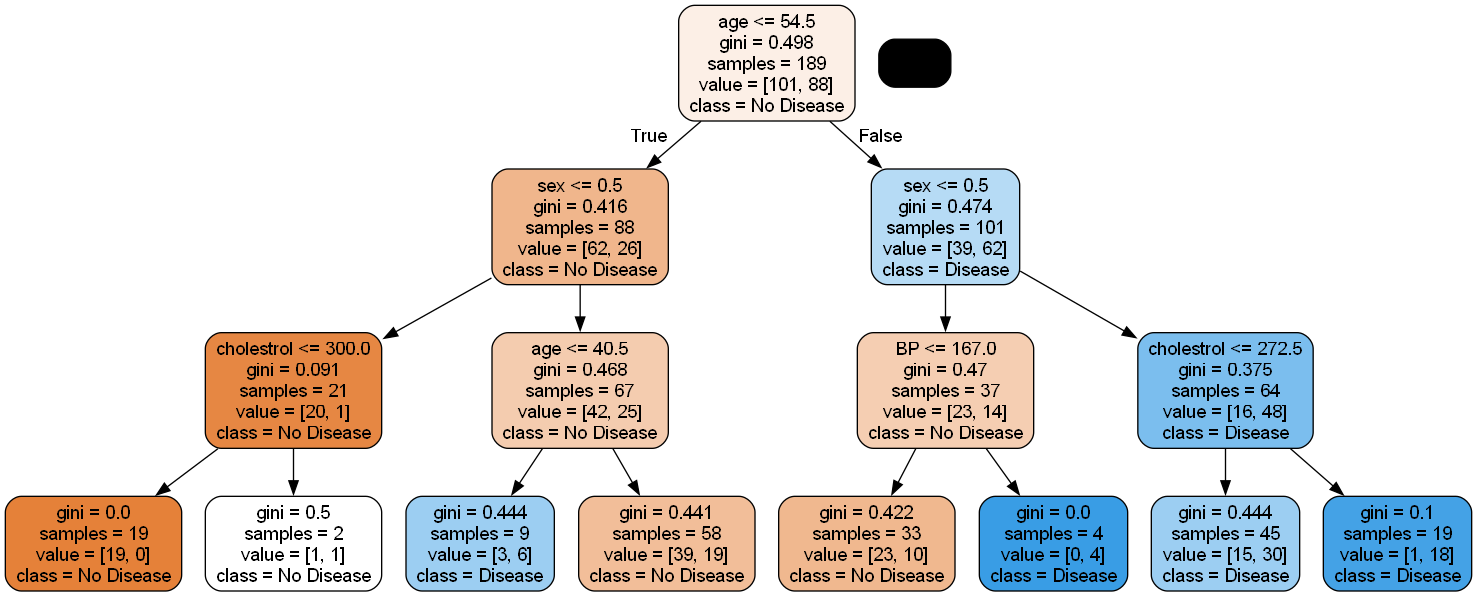

In [12]:
dot_data = StringIO()
export_graphviz(dt,out_file=dot_data,filled=True,rounded=True,
                feature_names=X.columns,class_names=['No Disease','Disease'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

# Model Evaluation

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [14]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [23]:
print("Train Metrics")
print(f'Accuracy score {accuracy_score(y_train,y_train_pred)}.')
print(f'Confusion Matrix {confusion_matrix(y_train,y_train_pred)}.')
print("Test Metrics")
print(f'Accuracy score {accuracy_score(y_test,y_test_pred)}.')
print(f'Confusion Matrix {confusion_matrix(y_test,y_test_pred)}.')

Train Metrics
Accuracy score 0.7407407407407407.
Confusion Matrix [[82 19]
 [30 58]].
Test Metrics
Accuracy score 0.6049382716049383.
Confusion Matrix [[35 14]
 [18 14]].


- Creating helper functions to evaluate model performance and help plot the decision tree

In [24]:
def get_dt_graph(dt_classifier):
    dot_data = StringIO()
    export_graphviz(dt_classifier,out_file=dot_data,filled=True,
                    rounded=True,feature_names=X.columns,class_names=["No Disease","Disease"])
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

    return graph

In [25]:
def evaluate_model(dt_classifier):
    print("Train Metrics")
    print(f'Accuracy score {accuracy_score(y_train,dt_classifier.predict(X_train))}.')
    print(f'Confusion Matrix {confusion_matrix(y_train,dt_classifier.predict(X_train))}.')
    print("Test Metrics")
    print(f'Accuracy score {accuracy_score(y_test,dt_classifier.predict(X_test))}.')
    print(f'Confusion Matrix {confusion_matrix(y_test,dt_classifier.predict(X_test))}.')

- Without setting any hyper-parameters

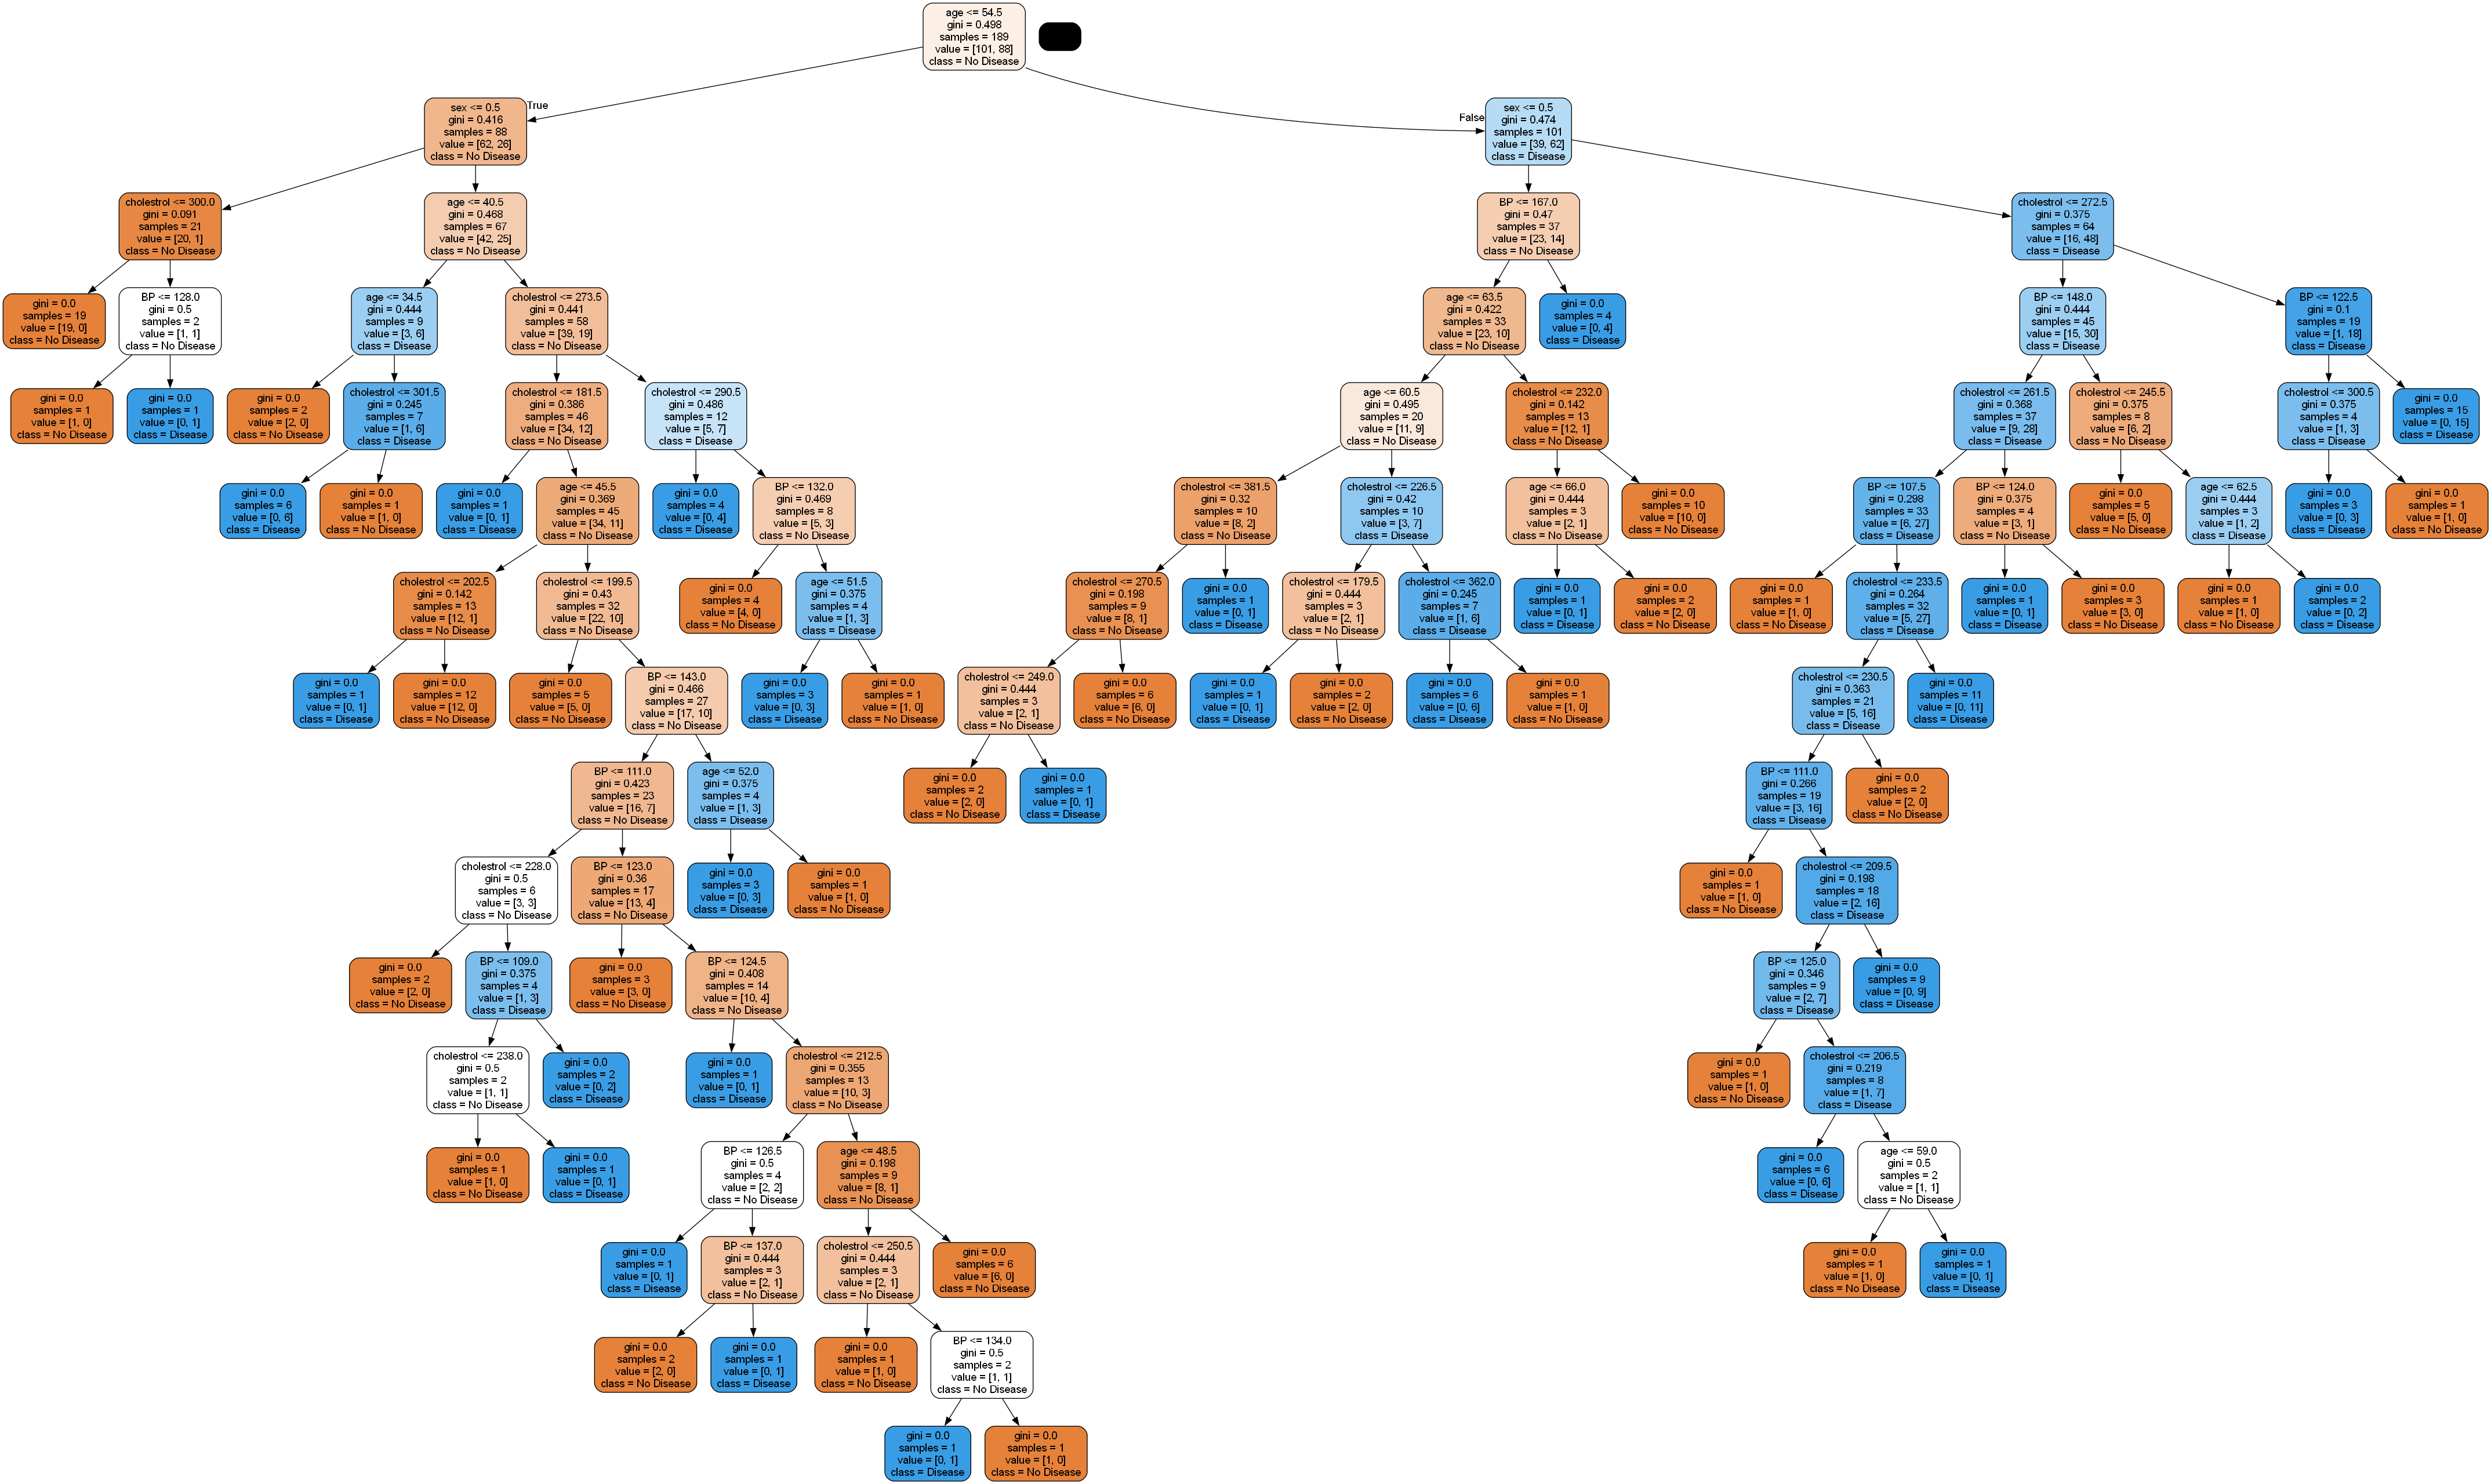

In [28]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train,y_train)
gph = get_dt_graph(dt_default)
Image(gph.create_png())


- Controlling Depths of the Tree

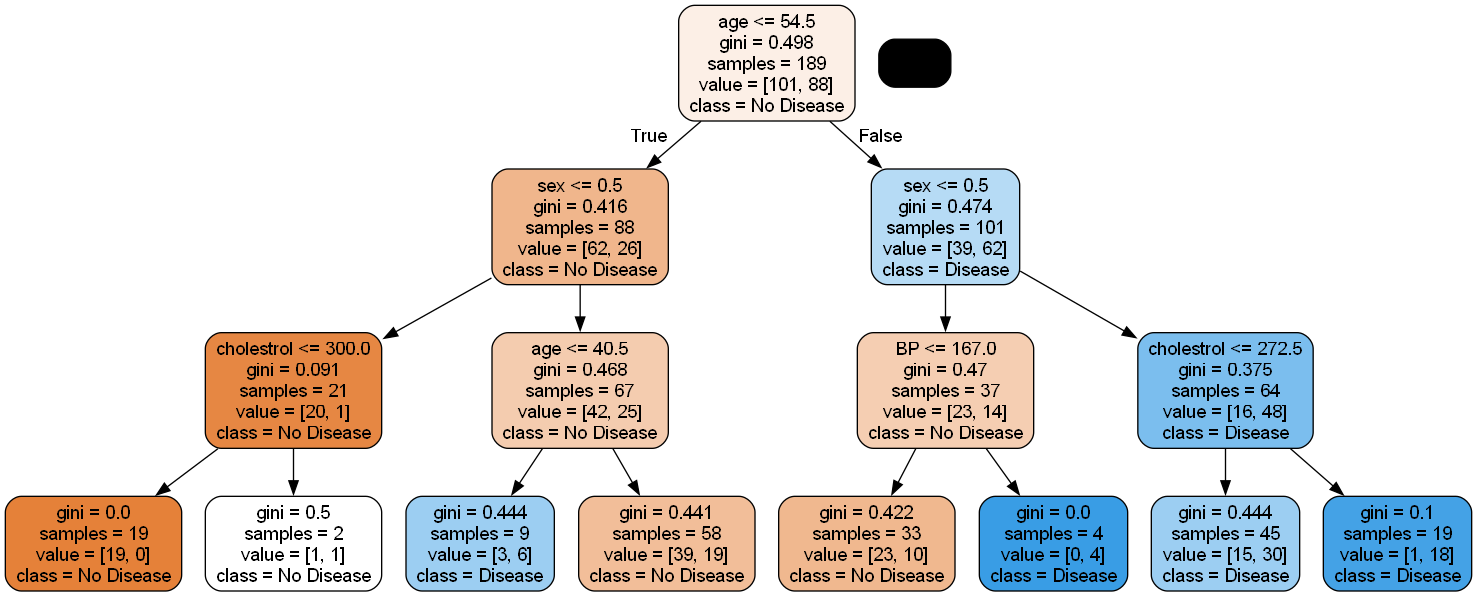

In [29]:
dt_depth = DecisionTreeClassifier(max_depth=3)
dt_depth.fit(X_train,y_train)
gph_depth = get_dt_graph(dt_depth)
Image(gph_depth.create_png())

- Specifying Minimum Samples Before Split

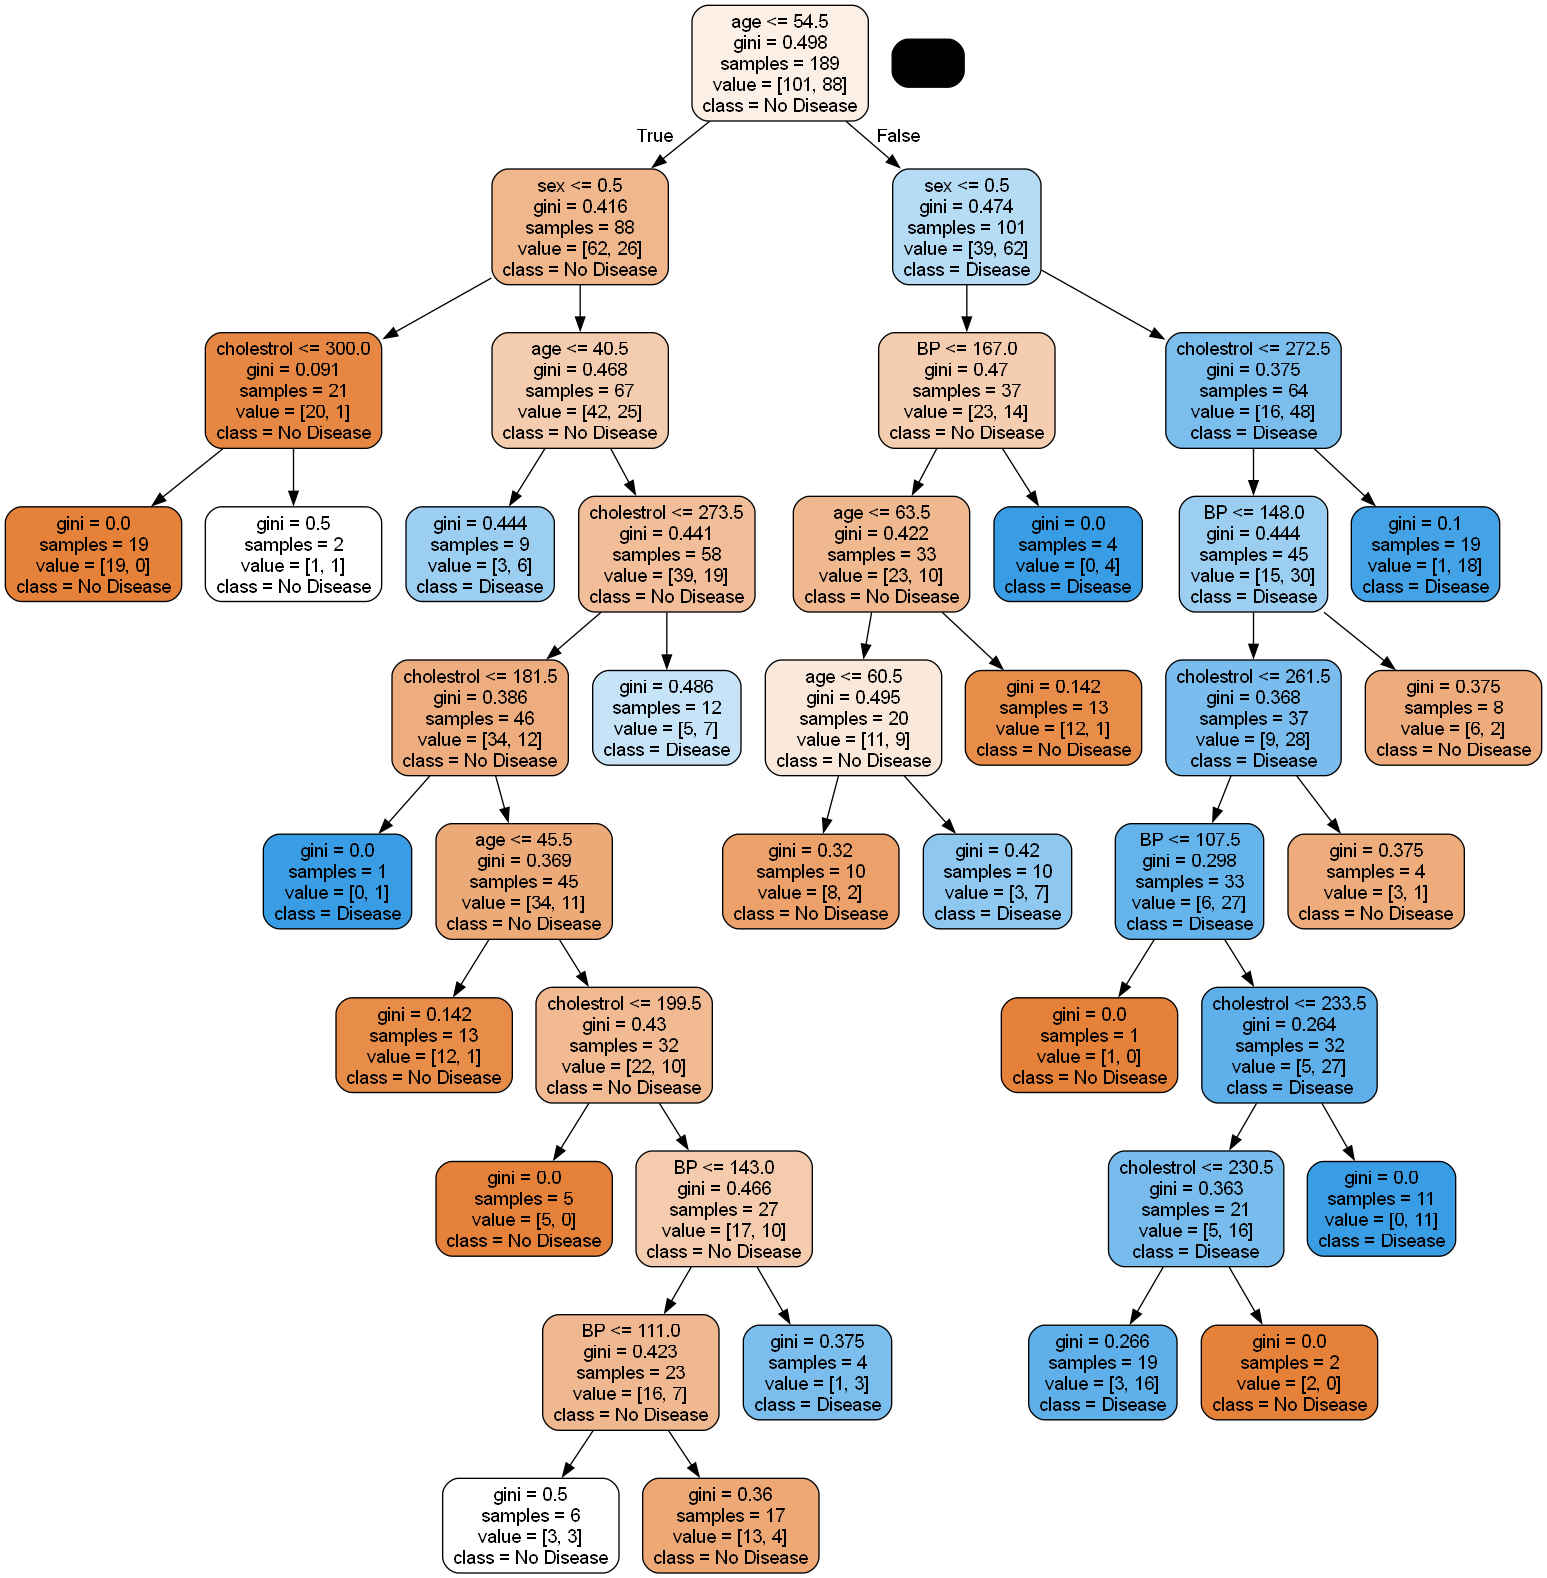

In [30]:
dt_min_split = DecisionTreeClassifier(min_samples_split=20)
dt_min_split.fit(X_train,y_train)
gph_min_split = get_dt_graph(dt_min_split)
Image(gph_min_split.create_png())

- Specifying Minimum Samples in Leafnode

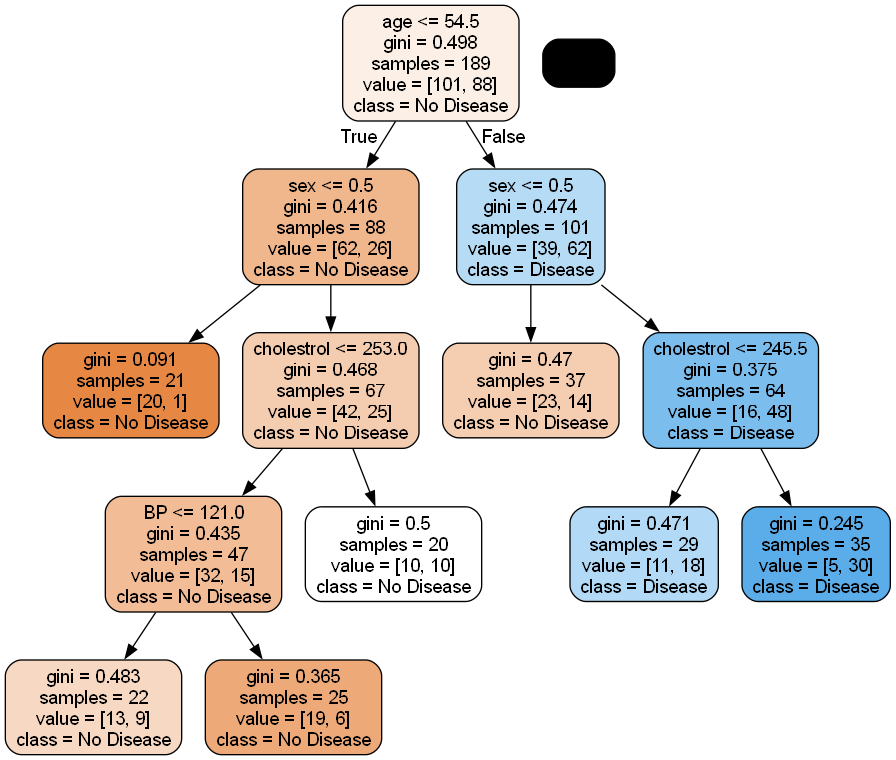

In [31]:
dt_min_leaf = DecisionTreeClassifier(min_samples_leaf=20,random_state=42)
dt_min_leaf.fit(X_train,y_train)
gph_min_leaf = get_dt_graph(dt_min_leaf)
Image(gph_min_leaf.create_png())

- Using Entropy Instead of Gini

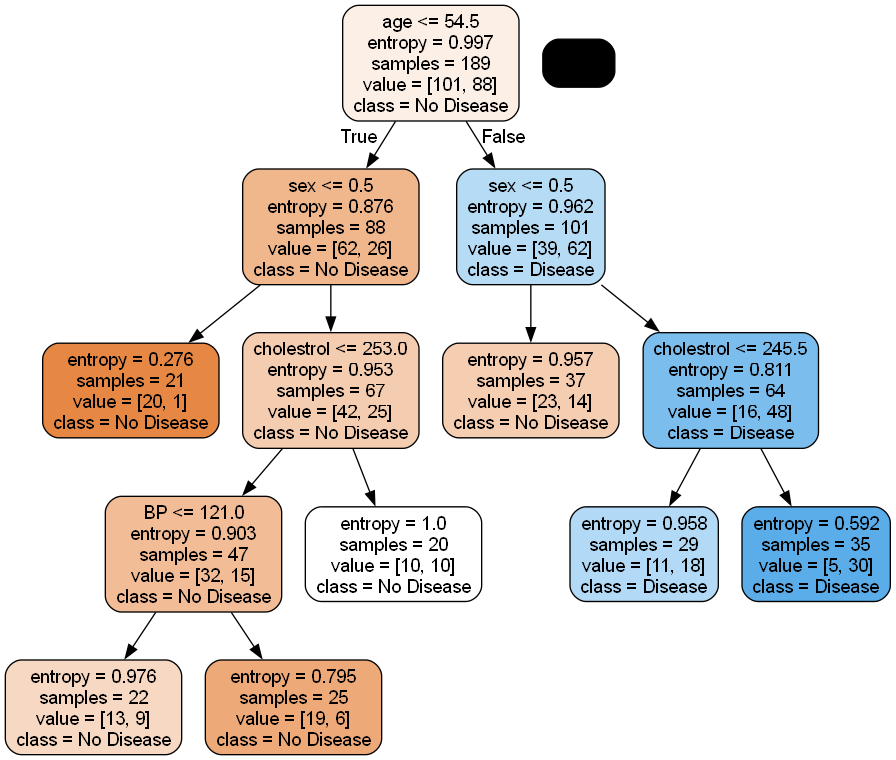

In [33]:
dt_min_leaf_entropy = DecisionTreeClassifier(min_samples_leaf=20,random_state=42,criterion="entropy")
dt_min_leaf_entropy.fit(X_train,y_train)
gph_entropy = get_dt_graph(dt_min_leaf_entropy)
Image(gph_entropy.create_png())

- Hyper-parameter Tuning

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
dt = DecisionTreeClassifier(random_state=42)

In [36]:
params = {
    'max_depth' : [2,3,5,10,20],
    'min_samples_leaf' : [5,10,20,50,100],
    'criterion' : ['gini','entropy']
}

- Instantiate gridsearchcv

In [37]:
grid_search = GridSearchCV(estimator=dt,param_grid=params,cv=4,n_jobs =-1, verbose=1,scoring='accuracy')

In [39]:
%%time
grid_search.fit(X_train,y_train)
score_df = pd.DataFrame(grid_search.cv_results_)
score_df.head()

Fitting 4 folds for each of 50 candidates, totalling 200 fits
CPU times: total: 281 ms
Wall time: 909 ms


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
0,0.006308,0.002571,0.007548,0.006823,gini,2,5,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.708333,0.744681,0.617021,0.531915,0.650488,0.082762,17
1,0.006822,0.002999,0.004386,0.003643,gini,2,10,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.708333,0.744681,0.617021,0.531915,0.650488,0.082762,17
2,0.008545,0.005433,0.007979,0.005952,gini,2,20,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.687500,0.744681,0.617021,0.531915,0.645279,0.079551,20
3,0.009921,0.007147,0.005069,0.002552,gini,2,50,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.666667,0.680851,0.574468,0.702128,0.656028,0.048751,3
4,0.006313,0.002921,0.011656,0.012049,gini,2,100,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.541667,0.531915,0.531915,0.531915,0.534353,0.004223,41


In [40]:
score_df.nlargest(5,"mean_test_score")

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
30,0.006161,0.004025,0.000000,0.000000,entropy,3,5,"{'criterion': 'entropy', 'max_depth': 3, 'min_...",0.604167,0.765957,0.617021,0.680851,0.666999,0.064090,1
5,0.007330,0.005785,0.011481,0.009302,gini,3,5,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.625000,0.744681,0.595745,0.659574,0.656250,0.055831,2
3,0.009921,0.007147,0.005069,0.002552,gini,2,50,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.666667,0.680851,0.574468,0.702128,0.656028,0.048751,3
8,0.010216,0.009931,0.005585,0.006995,gini,3,50,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.666667,0.680851,0.574468,0.702128,0.656028,0.048751,3
13,0.019465,0.022671,0.004935,0.003289,gini,5,50,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.666667,0.680851,0.574468,0.702128,0.656028,0.048751,3


- Best Estimator from Grid Search

In [41]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                       random_state=42)

In [42]:
dt_best = grid_search.best_estimator_
evaluate_model(dt_best)

Train Metrics
Accuracy score 0.7195767195767195.
Confusion Matrix [[82 19]
 [34 54]].
Test Metrics
Accuracy score 0.6172839506172839.
Confusion Matrix [[36 13]
 [18 14]].


- Classification Report for Best Estimator

In [43]:
from sklearn.metrics import classification_report

In [44]:
print(classification_report(y_test,dt_best.predict(X_test)))

              precision    recall  f1-score   support

           0       0.67      0.73      0.70        49
           1       0.52      0.44      0.47        32

    accuracy                           0.62        81
   macro avg       0.59      0.59      0.59        81
weighted avg       0.61      0.62      0.61        81



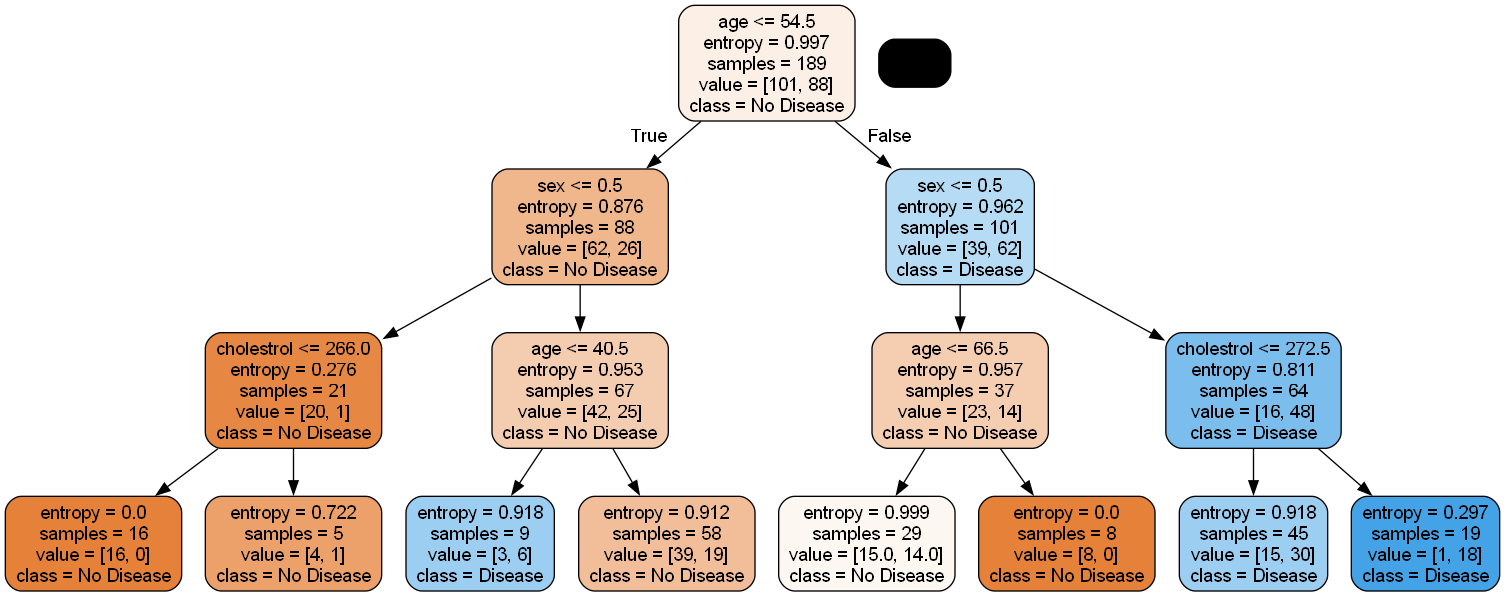

In [46]:
gph_best_estimator = get_dt_graph(dt_best)
Image(gph_best_estimator.create_png())